# Heart Disease Prediction – Individual Work
## Artificial Neural Network (ANN) for Binary Classification
**Module:** CS6053ES Artificial Intelligence and Machine Learning  
**Dataset:** Cleveland Heart Disease Dataset  
**Student ID:** E214008 
**Name:** Maha Gamage Ileesha Udari Sasmitha

---
## 1. Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)

np.random.seed(42)
print('All libraries imported successfully.')

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully.


---
## 2. Data Loading and Preprocessing
The same preprocessing pipeline used in the group work is applied here to ensure consistency and fair comparison between the ANN and the traditional models.

In [6]:
# Load dataset
df = pd.read_csv('Heart_disease_cleveland_new.csv')
df.columns = df.columns.str.strip()

print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [7]:
# Replace '?' with NaN
df = df.replace('?', np.nan)

# Define column types
numeric_cols     = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Impute numeric with median, categorical with mode
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Binarise target: 0 = No Disease, 1 = Disease
df['target'] = (df['target'] > 0).astype(int)

print('Missing values after cleaning:')
print(df.isnull().sum())
print('\nClass distribution:')
print(df['target'].value_counts())

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Class distribution:
target
0    164
1    139
Name: count, dtype: int64


In [8]:
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop('target', axis=1).values.astype(float)
y = df_encoded['target'].values.astype(float)

feature_names = df_encoded.drop('target', axis=1).columns.tolist()
print('Number of features after encoding:', X.shape[1])

# Stratified 80/20 split (same as group work)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardise features
scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_test_s   = scaler.transform(X_test)

print('Train shape:', X_train_s.shape)
print('Test shape: ', X_test_s.shape)

Number of features after encoding: 20
Train shape: (242, 20)
Test shape:  (61, 20)


In [9]:
# One-hot encode categorical columns
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

# Export cleaned dataset

# # Save cleaned and processed dataset
df_encoded.to_csv('cleaned_dataset.csv', index=False)

print("✅ Done! cleaned_dataset.csv saved in your project folder")

# Continue with train/test split
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

✅ Done! cleaned_dataset.csv saved in your project folder


---
## 3. Artificial Neural Network (ANN) – Built from Scratch

The ANN is implemented using NumPy only, without any deep learning framework.  
**Architecture:**
- Input layer: 20 neurons (one per feature)
- Hidden Layer 1: 32 neurons, ReLU activation
- Hidden Layer 2: 16 neurons, ReLU activation
- Output layer: 1 neuron, Sigmoid activation (binary classification)

**Training:** Mini-batch gradient descent with Binary Cross-Entropy loss.

In [10]:
#  Activation functions 
def sigmoid(z):
    """Sigmoid activation for output layer."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def relu(z):
    """ReLU activation for hidden layers."""
    return np.maximum(0, z)

def relu_backward(z):
    """Derivative of ReLU."""
    return (z > 0).astype(float)

# Loss function 
def binary_cross_entropy(y_true, y_pred):
    """Binary cross-entropy loss."""
    eps    = 1e-9
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(
        y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
    )

print('Activation and loss functions defined.')

Activation and loss functions defined.


In [11]:
# Network architecture 
n_input = X_train_s.shape[1]   # 20 features
n_h1    = 32                   # Hidden layer 1
n_h2    = 16                   # Hidden layer 2
n_out   = 1                    # Binary output

# Weight initialisation (He initialisation for ReLU layers) 
np.random.seed(42)
W1 = np.random.randn(n_input, n_h1) * np.sqrt(2.0 / n_input)
b1 = np.zeros((1, n_h1))

W2 = np.random.randn(n_h1, n_h2) * np.sqrt(2.0 / n_h1)
b2 = np.zeros((1, n_h2))

W3 = np.random.randn(n_h2, n_out) * np.sqrt(2.0 / n_h2)
b3 = np.zeros((1, n_out))

print('Network architecture:')
print(f'  Input  layer : {n_input} neurons')
print(f'  Hidden layer 1: {n_h1} neurons  [ReLU]')
print(f'  Hidden layer 2: {n_h2} neurons  [ReLU]')
print(f'  Output layer  : {n_out} neuron   [Sigmoid]')
print('\nTotal parameters:')
total = n_input*n_h1 + n_h1 + n_h1*n_h2 + n_h2 + n_h2*n_out + n_out
print(f'  {total} parameters')

Network architecture:
  Input  layer : 20 neurons
  Hidden layer 1: 32 neurons  [ReLU]
  Hidden layer 2: 16 neurons  [ReLU]
  Output layer  : 1 neuron   [Sigmoid]

Total parameters:
  1217 parameters


In [12]:
# Forward pass
def forward_pass(X):
    z1 = X  @ W1 + b1;  a1 = relu(z1)
    z2 = a1 @ W2 + b2;  a2 = relu(z2)
    z3 = a2 @ W3 + b3;  a3 = sigmoid(z3)
    return z1, a1, z2, a2, z3, a3

# Backward pass 
def backward_pass(X_batch, y_batch, z1, a1, z2, a2, a3):
    m    = len(y_batch)
    dz3  = a3 - y_batch

    dW3  = (a2.T @ dz3) / m
    db3  = dz3.mean(axis=0, keepdims=True)

    da2  = dz3 @ W3.T
    dz2  = da2 * relu_backward(z2)
    dW2  = (a1.T @ dz2) / m
    db2  = dz2.mean(axis=0, keepdims=True)

    da1  = dz2 @ W2.T
    dz1  = da1 * relu_backward(z1)
    dW1  = (X_batch.T @ dz1) / m
    db1  = dz1.mean(axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

print('Forward and backward pass functions defined.')

Forward and backward pass functions defined.


In [13]:
# Training loop 
learning_rate = 0.001
epochs        = 300
batch_size    = 32

train_loss_hist = []
val_loss_hist   = []
train_acc_hist  = []
val_acc_hist    = []

n_samples = X_train_s.shape[0]

for epoch in range(epochs):
    # Shuffle training data each epoch
    idx      = np.random.permutation(n_samples)
    X_shuf   = X_train_s[idx]
    y_shuf   = y_train[idx]

    # Mini-batch gradient descent
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuf[i : i + batch_size]
        y_batch = y_shuf[i : i + batch_size].reshape(-1, 1)

        z1, a1, z2, a2, z3, a3 = forward_pass(X_batch)
        dW1, db1, dW2, db2, dW3, db3 = backward_pass(
            X_batch, y_batch, z1, a1, z2, a2, a3
        )

        # Update weights
        W1 -= learning_rate * dW1;  b1 -= learning_rate * db1
        W2 -= learning_rate * dW2;  b2 -= learning_rate * db2
        W3 -= learning_rate * dW3;  b3 -= learning_rate * db3

    # Record epoch-level metrics
    _, _, _, _, _, tr_pred = forward_pass(X_train_s)
    _, _, _, _, _, va_pred = forward_pass(X_test_s)

    tl = binary_cross_entropy(y_train.reshape(-1, 1), tr_pred)
    vl = binary_cross_entropy(y_test.reshape(-1, 1),  va_pred)
    ta = ((tr_pred.flatten() > 0.5) == y_train).mean()
    va = ((va_pred.flatten() > 0.5) == y_test ).mean()

    train_loss_hist.append(tl)
    val_loss_hist.append(vl)
    train_acc_hist.append(ta)
    val_acc_hist.append(va)

print(f'Training complete ({epochs} epochs).')
print(f'Final training loss    : {train_loss_hist[-1]:.4f}')
print(f'Final validation loss  : {val_loss_hist[-1]:.4f}')
print(f'Final training accuracy: {train_acc_hist[-1]:.4f}')
print(f'Final validation accuracy: {val_acc_hist[-1]:.4f}')

Training complete (300 epochs).
Final training loss    : 0.3801
Final validation loss  : 0.3133
Final training accuracy: 0.8512
Final validation accuracy: 0.8852


---
## 4. Training Curves – Loss and Accuracy

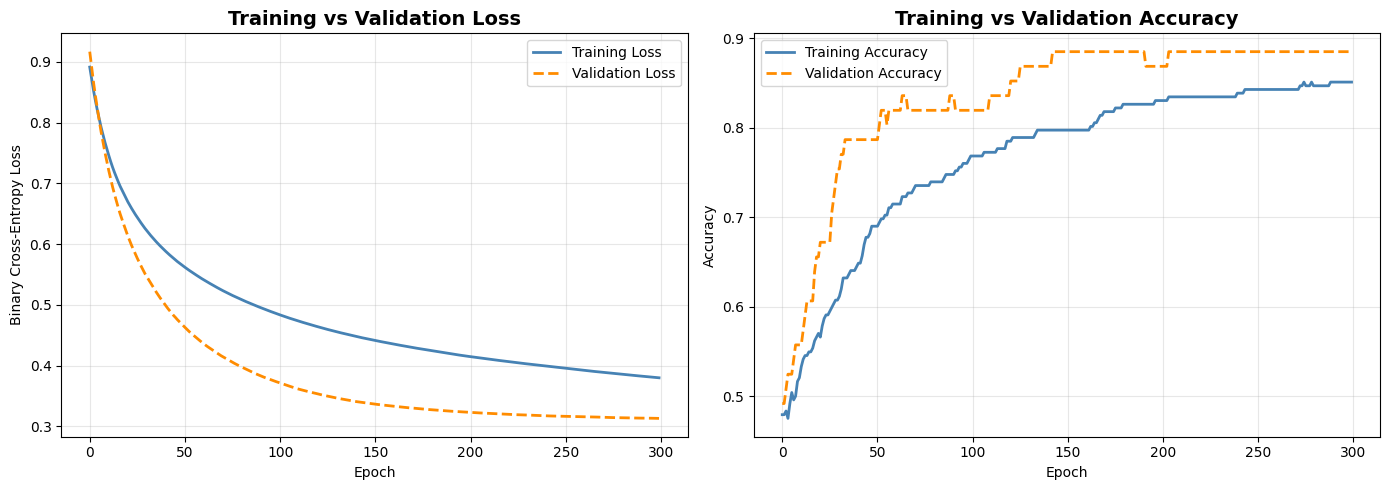

Figure saved: ann_training_curves.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_loss_hist, label='Training Loss',   color='steelblue',  linewidth=2)
axes[0].plot(val_loss_hist,   label='Validation Loss', color='darkorange', linewidth=2, linestyle='--')
axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(train_acc_hist, label='Training Accuracy',   color='steelblue',  linewidth=2)
axes[1].plot(val_acc_hist,   label='Validation Accuracy', color='darkorange', linewidth=2, linestyle='--')
axes[1].set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ann_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: ann_training_curves.png')

---
## 5. ANN Evaluation on Test Set

In [15]:
# Final predictions
_, _, _, _, _, y_prob_ann = forward_pass(X_test_s)
y_prob_ann = y_prob_ann.flatten()
y_pred_ann = (y_prob_ann > 0.5).astype(int)

# Compute metrics
ann_accuracy  = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann)
ann_recall    = recall_score(y_test, y_pred_ann)
ann_f1        = f1_score(y_test, y_pred_ann)
ann_roc_auc   = roc_auc_score(y_test, y_prob_ann)
ann_cm        = confusion_matrix(y_test, y_pred_ann)

print('=' * 45)
print('        ANN Test Set Performance')
print('=' * 45)
print(f'  Accuracy  : {ann_accuracy:.4f}')
print(f'  Precision : {ann_precision:.4f}')
print(f'  Recall    : {ann_recall:.4f}')
print(f'  F1-Score  : {ann_f1:.4f}')
print(f'  ROC-AUC   : {ann_roc_auc:.4f}')
print('=' * 45)
print('\nConfusion Matrix:')
print(ann_cm)
tn, fp, fn, tp = ann_cm.ravel()
print(f'  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_ann, target_names=['No Disease', 'Disease']))

        ANN Test Set Performance
  Accuracy  : 0.8852
  Precision : 0.8621
  Recall    : 0.8929
  F1-Score  : 0.8772
  ROC-AUC   : 0.9437

Confusion Matrix:
[[29  4]
 [ 3 25]]
  TN=29  FP=4  FN=3  TP=25

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.91      0.88      0.89        33
     Disease       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61



---
## 6. Confusion Matrix Visualisation

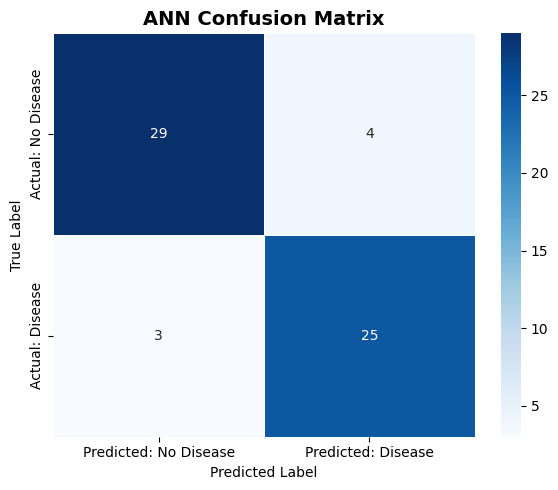

Figure saved: ann_confusion_matrix.png


In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    ann_cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: No Disease', 'Predicted: Disease'],
    yticklabels=['Actual: No Disease',    'Actual: Disease'],
    linewidths=0.5, ax=ax
)
ax.set_title('ANN Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('ann_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: ann_confusion_matrix.png')

---
## 7. ROC Curve – ANN

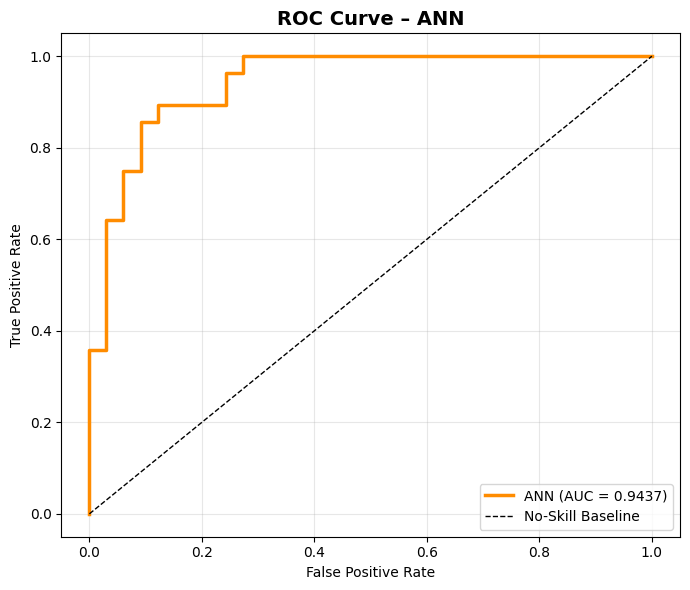

Figure saved: ann_roc_curve.png


In [17]:
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_ann, tpr_ann, color='darkorange', linewidth=2.5,
        label=f'ANN (AUC = {ann_roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='No-Skill Baseline')
ax.set_title('ROC Curve – ANN', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ann_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: ann_roc_curve.png')

---
## 8. Comparison with Traditional ML Models (Group Work)
The traditional model results from the group work are reproduced here for direct comparison.

In [18]:
#  Reproduce group traditional models on the SAME split 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Re-create the same split (already done above, reusing X_train_s, X_test_s)

# Group best parameters (from group report Table 2)
lr_model = LogisticRegression(C=0.1, solver='liblinear', random_state=42)
rf_model = RandomForestClassifier(max_depth=5, min_samples_split=5,
                                   n_estimators=200, random_state=42)
xgb_model = XGBClassifier(learning_rate=0.05, max_depth=3,
                           n_estimators=100, random_state=42,
                           eval_metric='logloss', verbosity=0)

# Train
lr_model.fit(X_train_s, y_train)
rf_model.fit(X_train_s, y_train)
xgb_model.fit(X_train_s, y_train)

# Predict
def get_metrics(model, Xte, yte, name):
    yp  = model.predict(Xte)
    ypr = model.predict_proba(Xte)[:, 1]
    cm  = confusion_matrix(yte, yp)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(yte, yp),   4),
        'Precision' : round(precision_score(yte, yp),  4),
        'Recall'    : round(recall_score(yte, yp),     4),
        'F1-Score'  : round(f1_score(yte, yp),         4),
        'ROC-AUC'   : round(roc_auc_score(yte, ypr),   4),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'y_prob'    : ypr
    }

res_lr  = get_metrics(lr_model,  X_test_s, y_test, 'Logistic Regression')
res_rf  = get_metrics(rf_model,  X_test_s, y_test, 'Random Forest')
res_xgb = get_metrics(xgb_model, X_test_s, y_test, 'XGBoost')
res_ann = {
    'Model': 'ANN',
    'Accuracy' : round(ann_accuracy,  4),
    'Precision': round(ann_precision, 4),
    'Recall'   : round(ann_recall,    4),
    'F1-Score' : round(ann_f1,        4),
    'ROC-AUC'  : round(ann_roc_auc,   4),
    'TN': ann_cm[0,0], 'FP': ann_cm[0,1],
    'FN': ann_cm[1,0], 'TP': ann_cm[1,1],
    'y_prob': y_prob_ann
}

# Summary table
cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'TN', 'FP', 'FN', 'TP']
comparison_df = pd.DataFrame([res_lr, res_rf, res_xgb, res_ann])[cols]
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TN,FP,FN,TP
0,Logistic Regression,0.8852,0.8621,0.8929,0.8772,0.9556,29,4,3,25
1,Random Forest,0.8689,0.8333,0.8929,0.8621,0.9481,28,5,3,25
2,XGBoost,0.8689,0.8571,0.8571,0.8571,0.9318,29,4,4,24
3,ANN,0.8852,0.8621,0.8929,0.8772,0.9437,29,4,3,25


---
## 9. ROC Curve – All Models Comparison

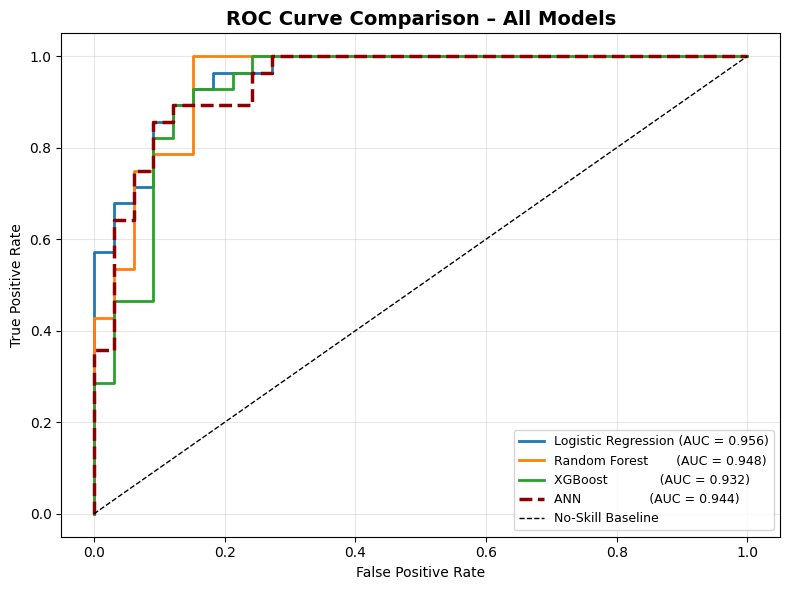

Figure saved: all_models_roc_comparison.png


In [19]:
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, res_lr['y_prob'])
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, res_rf['y_prob'])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, res_xgb['y_prob'])
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr,  tpr_lr,  linewidth=2,
        label=f"Logistic Regression (AUC = {res_lr['ROC-AUC']:.3f})")
ax.plot(fpr_rf,  tpr_rf,  linewidth=2,
        label=f"Random Forest       (AUC = {res_rf['ROC-AUC']:.3f})")
ax.plot(fpr_xgb, tpr_xgb, linewidth=2,
        label=f"XGBoost             (AUC = {res_xgb['ROC-AUC']:.3f})")
ax.plot(fpr_ann, tpr_ann, linewidth=2.5, linestyle='--', color='darkred',
        label=f"ANN                 (AUC = {res_ann['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='No-Skill Baseline')
ax.set_title('ROC Curve Comparison – All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('all_models_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: all_models_roc_comparison.png')

---
## 10. Bar Chart – All Models Performance Comparison

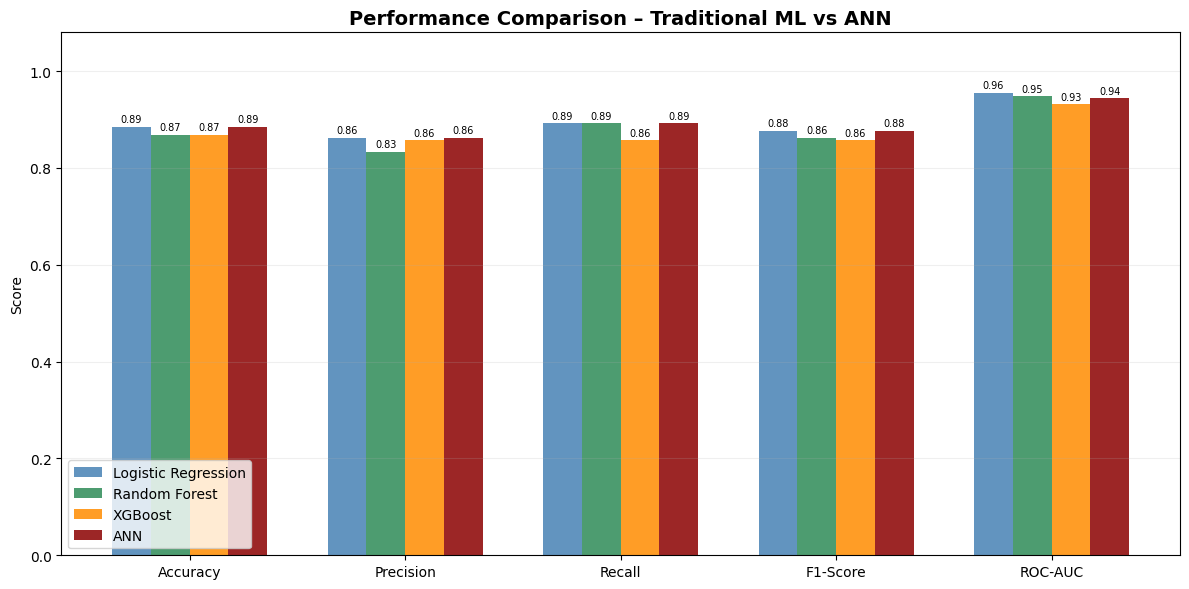

Figure saved: all_models_bar_comparison.png


In [20]:
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models   = ['Logistic Regression', 'Random Forest', 'XGBoost', 'ANN']
results  = [res_lr, res_rf, res_xgb, res_ann]
colors   = ['steelblue', 'seagreen', 'darkorange', 'darkred']

x     = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6))
for i, (model, res, color) in enumerate(zip(models, results, colors)):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_title('Performance Comparison – Traditional ML vs ANN',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.08)
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('all_models_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: all_models_bar_comparison.png')

---
## 11. Confusion Matrix Comparison – All Models

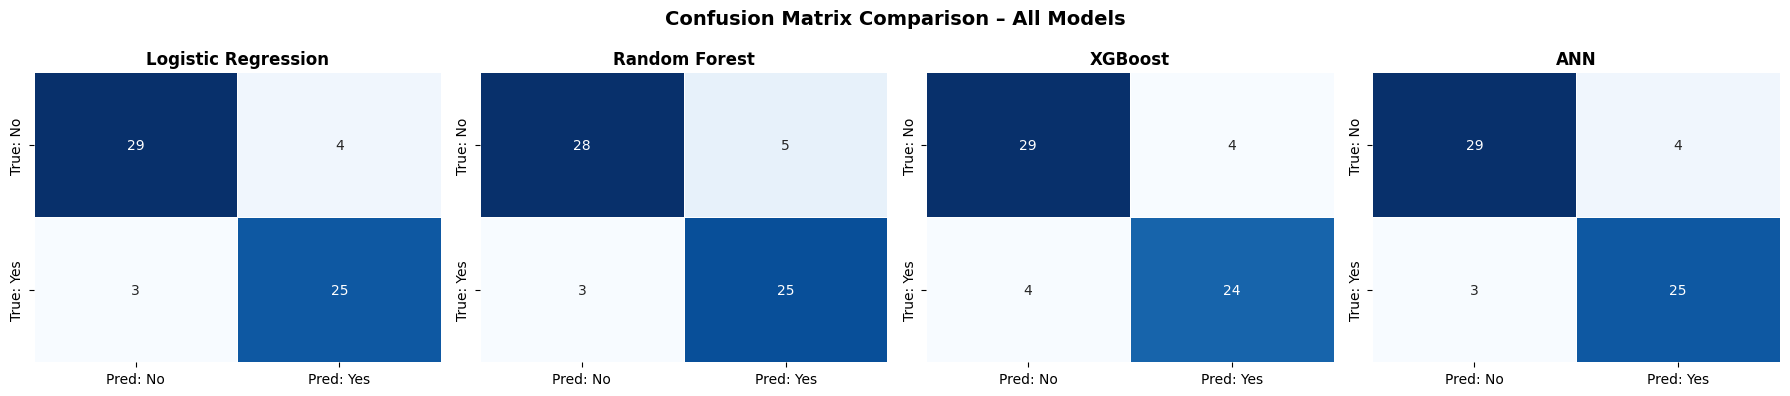

Figure saved: all_models_confusion_matrices.png


In [21]:
cms = [
    confusion_matrix(y_test, lr_model.predict(X_test_s)),
    confusion_matrix(y_test, rf_model.predict(X_test_s)),
    confusion_matrix(y_test, xgb_model.predict(X_test_s)),
    ann_cm
]
titles = ['Logistic Regression', 'Random Forest', 'XGBoost', 'ANN']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrix Comparison – All Models',
             fontsize=14, fontweight='bold')

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['True: No', 'True: Yes'],
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('all_models_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: all_models_confusion_matrices.png')

---
## 12. Summary

In [22]:
print('=' * 65)
print('       FINAL COMPARISON TABLE – ALL MODELS')
print('=' * 65)
print(comparison_df[['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']].to_string(index=False))
print('=' * 65)

best_acc = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
best_auc = comparison_df.loc[comparison_df['ROC-AUC'].idxmax(), 'Model']
print(f'\nHighest Accuracy : {best_acc}')
print(f'Highest ROC-AUC  : {best_auc}')

       FINAL COMPARISON TABLE – ALL MODELS
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8852     0.8621  0.8929    0.8772   0.9556
      Random Forest    0.8689     0.8333  0.8929    0.8621   0.9481
            XGBoost    0.8689     0.8571  0.8571    0.8571   0.9318
                ANN    0.8852     0.8621  0.8929    0.8772   0.9437

Highest Accuracy : Logistic Regression
Highest ROC-AUC  : Logistic Regression
